# HALO NYC methane inversion — step-by-step walkthrough

This notebook walks through a single-flight Bayesian flux inversion end to end, so you can see and tune each stage. It uses the generic `goe` framework (imported from the separate `goe-inversion` project) plus the HALO-specific adapters in `halo_oe`.

**The model.** Each HALO receptor is a column-averaged XCH4 observation. We write it as a background plus an enhancement driven by surface fluxes through a precomputed Jacobian `H`:

$$x_{\mathrm{obs}} = x_{\mathrm{bg}} + H\,f + \varepsilon$$

We solve for dimensionless per-cell **scalars** on a prior emission field, plus a per-flight background **offset**, by Bayesian optimal estimation:

$$\hat{x} = x_a + S_a H^\top\,(H S_a H^\top + R)^{-1}(z - H x_a),\qquad z = x_{\mathrm{obs}} - x_{\mathrm{bg}}$$

**Inventories.** EDGAR, EPA, and Pittsburgh are three *alternative* complete inventories of the same NYC emissions — they are **not** additive sectors, so one inversion uses exactly one as the prior. Step 7–10 use the configured primary inventory; step 11 re-inverts each one separately to show how prior-dependent the answer is.

**All settings are read from `halo_oe/config.ini`** — the same file the `run_halo.py` CLI uses — so the notebook and the command-line driver stay in agreement.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('halo_inversion_walkthrough.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401  (side effect: makes goe/adapters importable)

from goe import (GaussianLinearProblem, BlockDiagonalCovariance, DiagonalCovariance,
                 StateSpace, solve, reduced_chi_square)
from goe.config import Config
from adapters.gridded_state import GriddedState
from adapters.jacobian_operator import JacobianFile
from adapters.scaling_blocks import category_blocks, offset_block
from adapters.covariance_builders import build_spatial_covariance
from adapters.observations import build_observations
from halo_oe.emissions import category_priors_on_grid
from halo_oe.background import flight_background
from halo_oe.flux import estimate_fluxes
from halo_oe.pipeline import InversionContext, invert_with_inventory

# --- read ALL settings from the same config.ini the run_halo.py CLI uses ---
CONFIG_PATH = os.path.join(BAYES_OPT, 'halo_oe', 'config.ini')
cfg = Config(CONFIG_PATH)
_cfgdir = os.path.dirname(CONFIG_PATH)
def _resolve(p):
    return p if os.path.isabs(p) else os.path.normpath(os.path.join(_cfgdir, p))

JAC_PATH  = _resolve(cfg.get('jacobian', 'path'))
EMIS_PATH = _resolve(cfg.get('emissions', 'path'))
BBOX      = cfg.get_literal('domain', 'bbox')
INVENTORY = cfg.get('emissions', 'inventory', default='pitt')           # primary prior
COMPARE   = [s.strip() for s in cfg.get('emissions', 'compare', default='edgar,epa,pitt').split(',')]

DEGREE            = cfg.get_int('background', 'degree', default=1)
ENVELOPE_QUANTILE = cfg.get_float('background', 'envelope_quantile', default=0.25)
N_ITER            = cfg.get_int('background', 'n_iter', default=5)
SCALAR_STDDEV     = cfg.get_float('prior', 'scalar_stddev', default=0.5)
CORR_KM           = cfg.get_float('prior', 'correlation_length_km', default=5.0)
OBS_STDDEV        = cfg.get_float('observations', 'error_stddev', default=0.02)
N_OFFSETS         = cfg.get_int('offset', 'n_groups', default=1)
OFFSET_STDDEV     = cfg.get_float('offset', 'stddev', default=0.02)

print('config   :', CONFIG_PATH)
print('primary inventory (prior):', INVENTORY, '| compared:', COMPARE)
print(f'bbox={BBOX}  corr_km={CORR_KM}  scalar_sd={SCALAR_STDDEV}  obs_sd={OBS_STDDEV}  offset_sd={OFFSET_STDDEV}')

config   : /Volumes/Expansion/halo-nyc/bayes_opt/halo_oe/config.ini
primary inventory (prior): pitt | compared: ['edgar', 'epa', 'pitt']
bbox=[40.4, 41.1, -74.3, -73.5]  corr_km=5.0  scalar_sd=0.5  obs_sd=0.02  offset_sd=0.02


## 1. Open the Jacobian (metadata only)

Opening the file reads only the small coordinate/receptor variables; the multi-gigabyte Jacobian array is **not** loaded yet, so steps 1–5 are fast. Only step 6 touches the big array.

In [2]:
jf = JacobianFile(JAC_PATH)
grid = jf.grid
obs = jf.receptor_obs
rlat, rlon = jf.receptor_lat, jf.receptor_lon
print(f'receptors      : {jf.n_receptors}')
print(f'emission grid  : {grid.shape}  ({grid.n_cells:,} cells)')
print(f'observed XCH4  : mean {obs.mean():.4f}, range [{obs.min():.4f}, {obs.max():.4f}] ppm')

receptors      : 1271
emission grid  : (1666, 1666)  (2,775,556 cells)
observed XCH4  : mean 2.0148, range [1.9518, 2.0992] ppm


## 2. Inspect the observations

The receptors trace the flight track; color is the observed column XCH4 — elevated over/downwind of the urban core on a smoothly varying background.

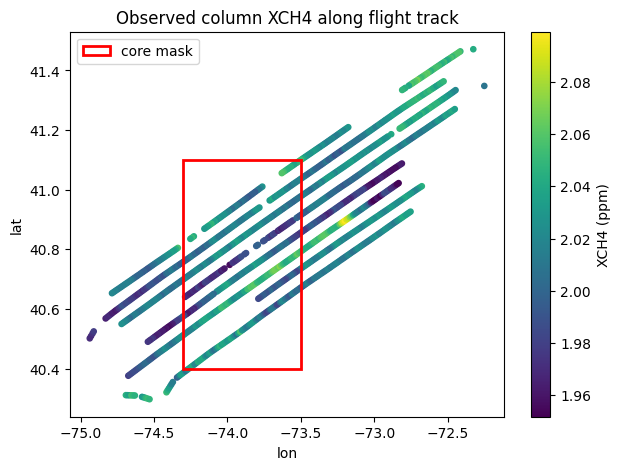

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(rlon, rlat, c=obs, s=14, cmap='viridis')
ax.add_patch(plt.Rectangle((BBOX[2], BBOX[0]), BBOX[3]-BBOX[2], BBOX[1]-BBOX[0],
                           fill=False, ec='red', lw=2, label='core mask'))
ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.set_title('Observed column XCH4 along flight track')
ax.legend(loc='upper left'); fig.colorbar(sc, label='XCH4 (ppm)'); plt.show()

## 3. Optimize the background → enhancements

The Jacobian explains only the *enhancement* from in-domain surface fluxes, so we remove the inflow/free-tropospheric **background** first via a **per-flight, lower-envelope plane** in (lat, lon): per-flight (captures day/time), lower-envelope (tracks clean air, won't bias fluxes low), degree 1 (too few DOF to chase the plume). Parameters come from config. The enhancement assimilated is `z = obs - background`.

In [4]:
bg = flight_background(rlat, rlon, obs, degree=DEGREE, quantile=ENVELOPE_QUANTILE, n_iter=N_ITER)
z = obs - bg
print(f'background : mean {bg.mean():.4f}, range [{bg.min():.4f}, {bg.max():.4f}] ppm  (varies in space)')
print(f'enhancement z : mean {z.mean():+.4f}, range [{z.min():+.4f}, {z.max():+.4f}] ppm, {np.mean(z>=0)*100:.0f}% positive')

background : mean 1.9767, range [1.9237, 2.0224] ppm  (varies in space)
enhancement z : mean +0.0380, range [-0.0246, +0.1355] ppm, 89% positive


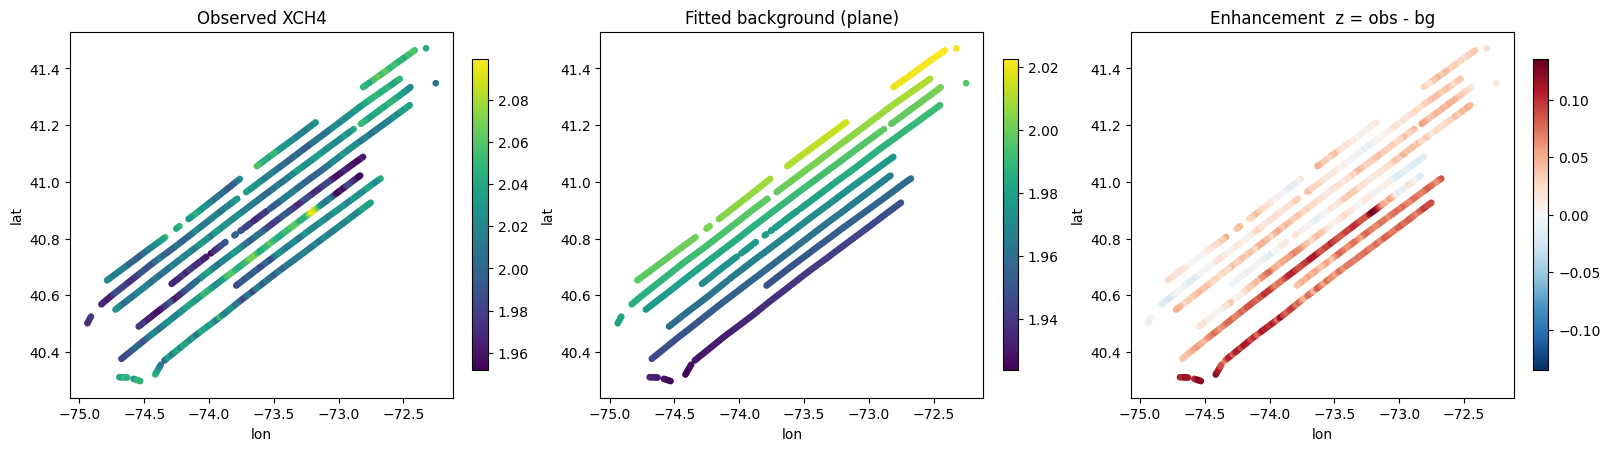

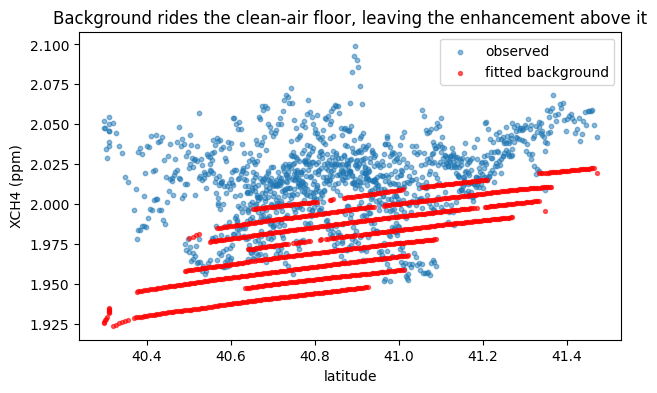

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
for a, (title, val, cmap) in zip(ax, [
        ('Observed XCH4', obs, 'viridis'),
        ('Fitted background (plane)', bg, 'viridis'),
        ('Enhancement  z = obs - bg', z, 'RdBu_r')]):
    vlim = None if cmap=='viridis' else max(abs(z.min()), abs(z.max()))
    kw = dict(vmin=-vlim, vmax=vlim) if vlim else {}
    s = a.scatter(rlon, rlat, c=val, s=14, cmap=cmap, **kw)
    a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(s, ax=a, shrink=0.85)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(rlat, obs, s=10, alpha=0.5, label='observed')
ax.scatter(rlat, bg, s=8, color='red', alpha=0.6, label='fitted background')
ax.set_xlabel('latitude'); ax.set_ylabel('XCH4 (ppm)'); ax.legend()
ax.set_title('Background rides the clean-air floor, leaving the enhancement above it'); plt.show()

## 4. Define the domain mask (state grid)

We solve for fluxes only on cells inside the NYC core box (`BBOX` from config); everything else is held at the prior. A coarse buffer ring around the core (to stop just-outside emissions aliasing inward) is omitted here for clarity.

In [6]:
mask = grid.bbox_mask(*BBOX)
core = GriddedState(grid, mask, name='core')
print(f'active core cells: {core.n_active:,} of {grid.n_cells:,}')

rows = np.where(mask.any(1))[0]; cols = np.where(mask.any(0))[0]
r0, r1, c0, c1 = rows[0], rows[-1]+1, cols[0], cols[-1]+1
EXTENT = [grid.lon[c0], grid.lon[c1-1], grid.lat[r0], grid.lat[r1-1]]
def crop(field2d):
    return field2d[r0:r1, c0:c1]

active core cells: 6,942 of 2,775,556


## 5. Build the prior emission fields (alternative inventories)

Each inventory in `COMPARE` is summed over its sub-categories and regridded onto the Jacobian grid. **These are alternative estimates of the same emissions** — note how different they are. The primary inversion uses only `INVENTORY`; the rest are used in the step-11 comparison.

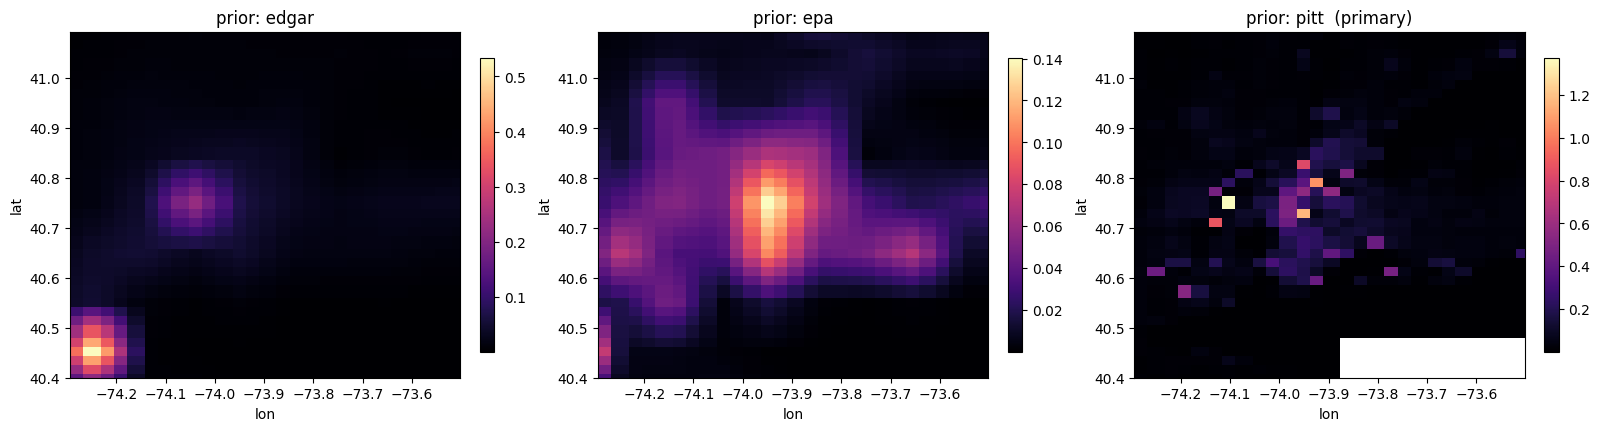

In [7]:
priors = category_priors_on_grid(EMIS_PATH, grid, sources=tuple(COMPARE))
fig, ax = plt.subplots(1, len(priors), figsize=(5.3*len(priors), 4.2), constrained_layout=True)
ax = np.atleast_1d(ax)
for a, name in zip(ax, priors):
    f = crop(priors[name]).copy(); f[f <= 0] = np.nan
    im = a.imshow(f, origin='lower', extent=EXTENT, aspect='auto', cmap='magma')
    title = f'prior: {name}' + ('  (primary)' if name == INVENTORY else '')
    a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(im, ax=a, shrink=0.85)
plt.show()

## 6. Build the forward operator  ⏳ (reads the large Jacobian)

The only slow step: stream the Jacobian once, keep the masked columns, return `H` over the active cells. This `base` operator is reused for every inventory.

In [8]:
base = jf.operator(active=core.active, in_memory=cfg.get_bool('jacobian', 'in_memory', default=True),
                   row_chunk=cfg.get_int('jacobian', 'row_chunk', default=24))
print(f'forward operator H : {base.shape[0]} obs x {base.shape[1]} active cells')

forward operator H : 1271 obs x 6942 active cells


## 7. Assemble the state and prior (primary inventory)

State = one **multiplicative-scalar block** on the primary inventory (`H·diag(prior)`) plus a per-flight background **offset**. The scalar block gets a compact-support spatially-correlated prior; the offset gets a tight prior so it nudges the level without absorbing signal.

In [9]:
cat_blocks, cat_ops = category_blocks(core, base, {INVENTORY: priors[INVENTORY]})
state_blocks = list(cat_blocks)
operators = dict(cat_ops)
cov_blocks = [build_spatial_covariance(core, SCALAR_STDDEV, CORR_KM)]

if N_OFFSETS > 0:
    assignments = (np.zeros(jf.n_receptors, dtype=int) if N_OFFSETS == 1
                   else np.arange(jf.n_receptors) % N_OFFSETS)
    off_blk, off_op = offset_block(assignments, n_groups=N_OFFSETS, name='bc')
    state_blocks.append(off_blk); operators['bc'] = off_op
    cov_blocks.append(DiagonalCovariance.isotropic(N_OFFSETS, OFFSET_STDDEV**2))

state = StateSpace(state_blocks)
H = state.block_column(operators)
Sa = BlockDiagonalCovariance(cov_blocks)
xa = state.fill(0.0, **{b.name: (0.0 if b.name == 'bc' else 1.0) for b in state.blocks})
obs_data = build_observations(obs, error_stddev=OBS_STDDEV, baseline=bg)  # z = obs - bg
print('state blocks:', [(b.name, b.size) for b in state.blocks], '-> dim', state.size)

state blocks: [('pitt', 6942), ('bc', 1)] -> dim 6943


## 8. Solve

Observation-space form is chosen automatically (far fewer observations than unknowns). Reduced chi-square near 1 means well-scaled errors; large values flag too-tight errors or an under-resolved domain.

In [10]:
problem = GaussianLinearProblem(H=H, z=obs_data.z, xa=xa, Sa=Sa, R=obs_data.R)
posterior = solve(problem)
print(f'inventory: {INVENTORY}  |  solved via {posterior.strategy}-space form')
print(f'reduced chi-square : {reduced_chi_square(problem, posterior):.3f}')
if 'bc' in state.names:
    print(f'fitted background offset (bc): {state.unpack(posterior.mean)["bc"][0]:+.4f} ppm')

inventory: pitt  |  solved via observation-space form


reduced chi-square : 2.412
fitted background offset (bc): +0.0345 ppm


## 9. Map the posterior scalars (primary inventory)

Values near 1 leave the inventory unchanged; <1 / >1 pull emissions down / up. The posterior relaxes to the prior where the data have little sensitivity (see the uncertainty map).

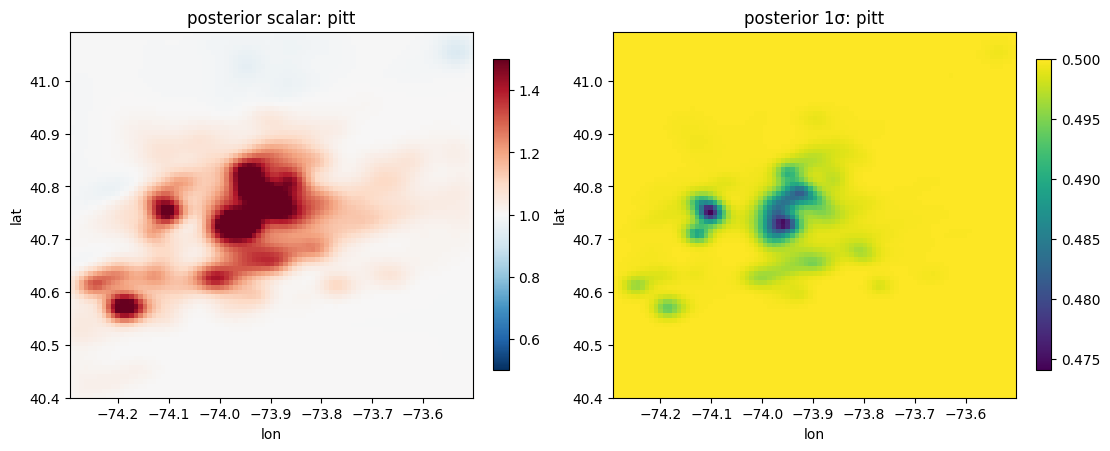

In [11]:
parts = state.unpack(posterior.mean); stds = state.unpack(posterior.stddev())
sfield = crop(core.to_field(parts[INVENTORY])); ufield = crop(core.to_field(stds[INVENTORY]))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
im0 = ax[0].imshow(sfield, origin='lower', extent=EXTENT, aspect='auto', cmap='RdBu_r', vmin=0.5, vmax=1.5)
ax[0].set_title(f'posterior scalar: {INVENTORY}'); fig.colorbar(im0, ax=ax[0], shrink=0.85)
im1 = ax[1].imshow(ufield, origin='lower', extent=EXTENT, aspect='auto', cmap='viridis')
ax[1].set_title(f'posterior 1\u03c3: {INVENTORY}'); fig.colorbar(im1, ax=ax[1], shrink=0.85)
for a in ax: a.set_xlabel('lon'); a.set_ylabel('lat')
plt.show()

## 10. Aggregate to an integrated flux (primary inventory)

Integrate `scalar x prior x cell-area` over the domain → total emission for this inventory, prior vs posterior, with uncertainty from the posterior covariance. (No cross-inventory total — the inventories are alternatives.)

In [12]:
report = estimate_fluxes(posterior, state, core, {INVENTORY: priors[INVENTORY]}, grid, prior_state=xa,
                         unit_scale=cfg.get_float('flux', 'unit_scale', default=1.0),
                         unit_label=cfg.get('flux', 'unit_label', default='prior-units x m^2 (native)'))
print(report.as_table())

category              prior      posterior         ± 1σ    scale
----------------------------------------------------------------
pitt              2.467e+08      3.118e+08    1.106e+07    1.264

units: prior-units x m^2 (native)


## 11. Compare inventories (prior sensitivity)

Because EDGAR, EPA, and Pittsburgh are *alternative* priors, we invert each **separately** (reusing the same Jacobian read via `pipeline.invert_with_inventory`) and compare the posterior totals. The spread across them measures how much the flux estimate depends on the choice of prior — they must **not** be summed.

inventory           prior      posterior          ±1σ    scale   chi2_r
----------------------------------------------------------------------
edgar           1.453e+08      1.744e+08     7.93e+06    1.200    2.528
epa             1.301e+08       1.45e+08    4.884e+06    1.115    2.542
pitt            2.467e+08      3.118e+08    1.106e+07    1.264    2.412


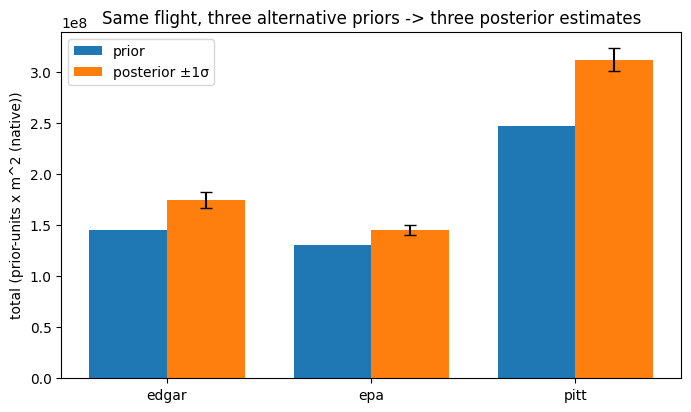

In [13]:
ctx = InversionContext(cfg=cfg, jf=jf, grid=grid, core=core, base=base,
                       background=bg, obs=obs_data, priors=priors)
results = {inv: invert_with_inventory(ctx, inv) for inv in COMPARE}

print(f"{'inventory':<10} {'prior':>14} {'posterior':>14} {'\u00b11\u03c3':>12} {'scale':>8} {'chi2_r':>8}")
print('-'*70)
for inv in COMPARE:
    r = results[inv].report
    print(f'{inv:<10} {r.prior[0]:>14.4g} {r.posterior[0]:>14.4g} {r.posterior_stddev[0]:>12.4g} '
          f'{r.scale_factor[0]:>8.3f} {results[inv].diagnostics["reduced_chi_square"]:>8.3f}')

x = np.arange(len(COMPARE)); w = 0.38
pri = [results[i].report.prior[0] for i in COMPARE]
pos = [results[i].report.posterior[0] for i in COMPARE]
err = [results[i].report.posterior_stddev[0] for i in COMPARE]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, pri, w, label='prior')
ax.bar(x + w/2, pos, w, yerr=err, capsize=4, label='posterior \u00b11\u03c3')
ax.set_xticks(x); ax.set_xticklabels(COMPARE); ax.set_ylabel(f'total ({report.unit_label})')
ax.set_title('Same flight, three alternative priors -> three posterior estimates')
ax.legend(); plt.show()

## Where this stands, and what's next

You followed a full single-flight inversion — observations → per-flight planar background → enhancements → masked forward operator → single-inventory scalar state + spatial prior → solve → posterior maps → integrated flux — and then compared the three alternative inventory priors. Every setting came from `halo_oe/config.ini`, matching the `run_halo.py` CLI (`--compare` reproduces step 11).

Remaining steps toward a defensible number:

1. **Multi-flight assimilation** — stack all six flights (each with its own background/offset) into one problem.
2. **Domain + buffer** — enlarge the core and add a coarse buffer ring (a small box under-resolves the plume; watch reduced chi-square).
3. **Error budget** — add a model–data mismatch term to `R`; justify the prior width and correlation length; tune so reduced chi-square ~ 1.
4. **Units** — confirm the inventory emission units and set `unit_scale` to report e.g. kt CH4 / yr.
5. **Sub-categories** — optionally split one inventory's sectors (landfills, wastewater, …) into *additive* blocks that legitimately sum to that inventory's total.
6. **Sensitivity** — vary background quantile, prior width, correlation length.